# Perbandingan Klasifikasi KNN vs Random Forest (HOG + PCA)
Notebook ini membandingkan kinerja model **K-Nearest Neighbors (KNN)** dan **Random Forest** dalam mengklasifikasikan APD (Helm dan Kacamata) menggunakan ekstraksi fitur HOG dan reduksi dimensi PCA.

In [1]:
import cv2
import numpy as np
import os
import glob
from tqdm.notebook import tqdm
from skimage.feature import hog

IMG_SIZE = (64, 64)

def extract_features_hog(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None

    # Resize dan konversi ke Grayscale
    img_resized = cv2.resize(img, IMG_SIZE)
    img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
    
    # Ekstraksi fitur HOG (Histogram of Oriented Gradients)
    features = hog(img_gray, orientations=9, pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2), block_norm='L2-Hys', visualize=False)
    return features

train_dir = "dataset/train"
categories = {"helm": 0, "kacamata": 1}

X_train_list = []
y_train_list = []

for label_name, label_id in categories.items():
    folder = os.path.join(train_dir, label_name)
    files = glob.glob(os.path.join(folder, "*.*"))
    print(f"Memproses '{label_name}': {len(files)} gambar ditemukan...")

    for img_path in tqdm(files, desc=f"Ekstraksi {label_name}"):
        features = extract_features_hog(img_path)
        if features is not None:
            X_train_list.append(features)
            y_train_list.append(label_id)

X = np.array(X_train_list)
y = np.array(y_train_list)

print(f"\nEkstraksi selesai! Dimensi Matriks Fitur Asli (X): {X.shape}")


Memproses 'helm': 1436 gambar ditemukan...


Ekstraksi helm:   0%|          | 0/1436 [00:00<?, ?it/s]

Memproses 'kacamata': 754 gambar ditemukan...


Ekstraksi kacamata:   0%|          | 0/754 [00:00<?, ?it/s]


Ekstraksi selesai! Dimensi Matriks Fitur Asli (X): (2190, 1764)


In [2]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("Standarisasi dan PCA...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=100, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Dimensi Matriks Fitur setelah PCA: {X_pca.shape}")

Standarisasi dan PCA...
Dimensi Matriks Fitur setelah PCA: (2190, 100)


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

X_tr, X_val, y_tr, y_val = train_test_split(X_pca, y, test_size=0.2, random_state=42, stratify=y)

print("Melatih model K-Nearest Neighbors (KNN)...")
knn_model = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
knn_model.fit(X_tr, y_tr)

print("Melatih model Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_tr, y_tr)

print("Pelatihan kedua model selesai!")

Melatih model K-Nearest Neighbors (KNN)...
Melatih model Random Forest...
Pelatihan kedua model selesai!


Memproses 76 gambar data test...


Evaluasi Test Data:   0%|          | 0/76 [00:00<?, ?it/s]

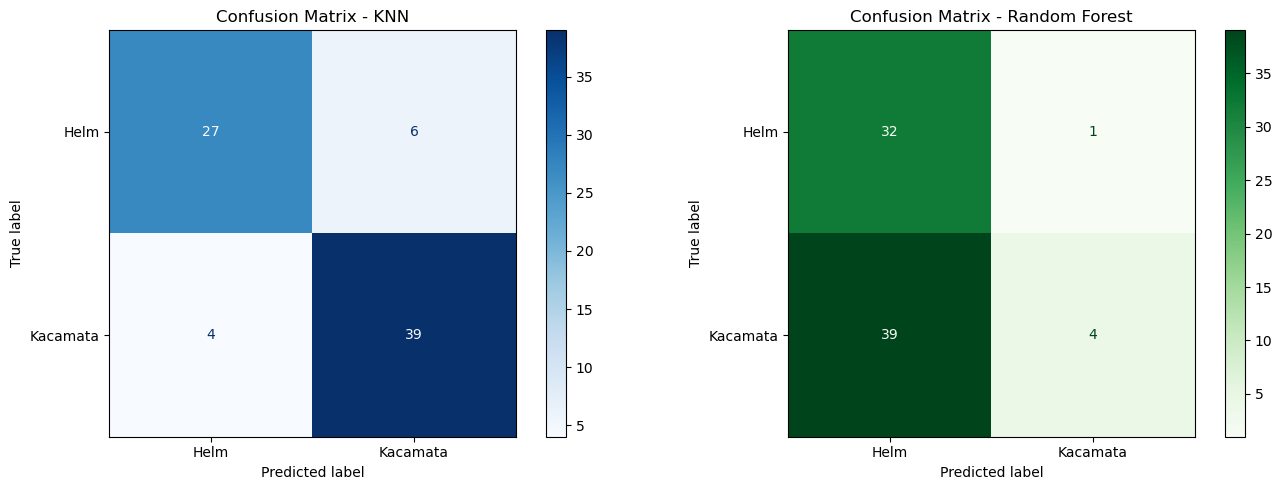


--- CLASSIFICATION REPORT KNN ---
              precision    recall  f1-score   support

        Helm       0.87      0.82      0.84        33
    Kacamata       0.87      0.91      0.89        43

    accuracy                           0.87        76
   macro avg       0.87      0.86      0.87        76
weighted avg       0.87      0.87      0.87        76


--- CLASSIFICATION REPORT RANDOM FOREST ---
              precision    recall  f1-score   support

        Helm       0.45      0.97      0.62        33
    Kacamata       0.80      0.09      0.17        43

    accuracy                           0.47        76
   macro avg       0.63      0.53      0.39        76
weighted avg       0.65      0.47      0.36        76



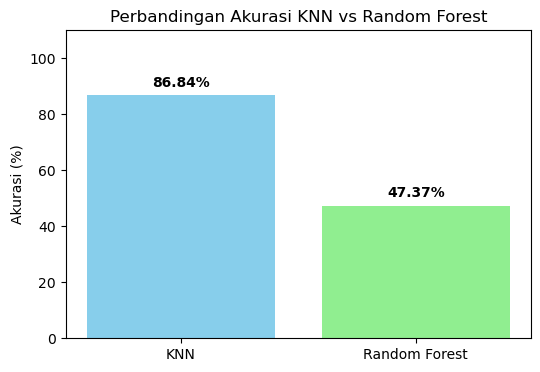

In [4]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

test_dir = "dataset/test"
test_files = glob.glob(os.path.join(test_dir, "*", "*.*"))

y_true = []
y_pred_knn = []
y_pred_rf = []

print(f"Memproses {len(test_files)} gambar data test...")

for img_path in tqdm(test_files, desc="Evaluasi Test Data"):
    parent = os.path.basename(os.path.dirname(img_path))
    actual = "Helm" if parent.lower() == "helm" else "Kacamata"
    y_true.append(actual)
    
    img = cv2.imread(img_path)
    if img is not None:
        features = extract_features_hog(img_path)
        features_scaled = scaler.transform([features])
        features_pca = pca.transform(features_scaled)
        
        pred_knn_id = knn_model.predict(features_pca)[0]
        y_pred_knn.append("Helm" if pred_knn_id == 0 else "Kacamata")

        pred_rf_id = rf_model.predict(features_pca)[0]
        y_pred_rf.append("Helm" if pred_rf_id == 0 else "Kacamata")
    else:
        y_pred_knn.append("Error")
        y_pred_rf.append("Error")

labels = ["Helm", "Kacamata"]

# Plot Confusion Matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_knn = confusion_matrix(y_true, y_pred_knn, labels=labels)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=labels)
disp_knn.plot(ax=axes[0], cmap="Blues")
axes[0].set_title("Confusion Matrix - KNN")

cm_rf = confusion_matrix(y_true, y_pred_rf, labels=labels)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=labels)
disp_rf.plot(ax=axes[1], cmap="Greens")
axes[1].set_title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()

print("\n--- CLASSIFICATION REPORT KNN ---")
print(classification_report(y_true, y_pred_knn, labels=labels, zero_division=0))

print("\n--- CLASSIFICATION REPORT RANDOM FOREST ---")
print(classification_report(y_true, y_pred_rf, labels=labels, zero_division=0))

# Perbandingan Akurasi
acc_knn = accuracy_score(y_true, y_pred_knn)
acc_rf = accuracy_score(y_true, y_pred_rf)

plt.figure(figsize=(6, 4))
bars = plt.bar(["KNN", "Random Forest"], [acc_knn * 100, acc_rf * 100], color=["skyblue", "lightgreen"])
plt.ylabel("Akurasi (%)")
plt.title("Perbandingan Akurasi KNN vs Random Forest")
plt.ylim(0, 110)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 2, f"{height:.2f}%", ha='center', va='bottom', fontweight='bold')
plt.show()
